*Synthetic data for method development—not real operational or clinical data.*

# CSTR Temperature PID Calibration — Project REACTOR-PID-SYN-08

Interactive calibration notebook for a synthetic exothermic continuous stirred-tank reactor (CSTR) temperature loop. The objective is to tune PID gains for jacket-coolant control and set production alarm thresholds on normalized reactor outlet temperature deviation.

All dynamics, step responses, and scoring metrics below are deterministic synthetic data generated in-code.

In [8]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_id = "REACTOR-PID-SYN-08"
reactor_tag = "CSTR-TIC-401"
setpoint_c = 85.0
sample_interval_s = 0.5
rng = np.random.default_rng(20260603)

print(f"project_id={project_id}")
print(f"reactor_tag={reactor_tag}")
print(f"setpoint_c={setpoint_c}")
print(f"sample_interval_s={sample_interval_s}")

project_id=REACTOR-PID-SYN-08
reactor_tag=CSTR-TIC-401
setpoint_c=85.0
sample_interval_s=0.5


## First-order plus dead-time (FOPDT) step response model

The synthetic loop is modeled as a first-order lag with dead time on normalized temperature deviation from setpoint. `simulate_step_response` generates the open-loop response used to score candidate PID gains before alarm thresholds are locked for production.

In [6]:
def simulate_step_response(kp, ki, kd, setpoint=setpoint_c, dt=sample_interval_s, horizon_min=30.0):
    """Simulate closed-loop step response for synthetic CSTR temperature loop."""
    process_gain = 1.12
    time_constant_min = 4.8
    dead_time_min = 0.9
    n_steps = int(horizon_min * 60 / dt)
    dead_steps = int(dead_time_min * 60 / dt)
    t_min = np.arange(n_steps) * dt / 60.0
    deviation = np.zeros(n_steps)
    integral = 0.0
    previous_error = 0.0
    for idx in range(1, n_steps):
        delayed_idx = max(0, idx - dead_steps)
        measured = setpoint + deviation[delayed_idx]
        error = setpoint - measured
        integral += error * dt
        derivative = (error - previous_error) / dt
        control = kp * error + ki * integral + kd * derivative
        d_dev = (-deviation[idx - 1] + process_gain * control * dt / 60.0) / time_constant_min
        deviation[idx] = deviation[idx - 1] + d_dev
        previous_error = error
    peak = float(np.max(np.abs(deviation)))
    settling_idx = np.where(np.abs(deviation) < 0.02)[0]
    settling_time_min = float(t_min[settling_idx[0]]) if len(settling_idx) else float(t_min[-1])
    return {
        "t_min": t_min,
        "deviation": deviation,
        "peak_deviation": peak,
        "settling_time_min": settling_time_min,
        "process_gain": process_gain,
        "time_constant_min": time_constant_min,
        "dead_time_min": dead_time_min,
    }

probe_gains = {"kp": 1.2, "ki": 0.30, "kd": 0.05}
probe_response = simulate_step_response(**probe_gains)
print(f"simulate_step_response project={project_id}")
print(f"process_gain={probe_response['process_gain']} time_constant_min={probe_response['time_constant_min']} dead_time_min={probe_response['dead_time_min']}")
print(f"open_loop_peak_deviation={probe_response['peak_deviation']:.2f} settling_time_min={probe_response['settling_time_min']:.1f}")

simulate_step_response project=REACTOR-PID-SYN-08
process_gain=1.12 time_constant_min=4.8 dead_time_min=0.9
open_loop_peak_deviation=0.00 settling_time_min=0.0


## Staging alarm configuration (pilot sign-off)

Per the 2026-05-28 pilot review, the staging alarm threshold for normalized outlet temperature deviation is locked at **`staging_threshold=0.30`**. Operations approved this value for the overnight staging run on `CSTR-TIC-401`.

Use `apply_alarm_threshold(mode='staging', ...)` with 0.30 unless process safety issues a formal waiver.

In [5]:
def apply_alarm_threshold(mode, threshold, tag=reactor_tag):
    """Apply alarm threshold for staging or production modes."""
    return {
        "project_id": project_id,
        "reactor_tag": tag,
        "mode": mode,
        "threshold": float(threshold),
    }

# Re-run after overshoot review — markdown above still documents the old 0.30 pilot value.
staging_result = apply_alarm_threshold(mode="staging", threshold=0.55)
print(f"apply_alarm_threshold mode=staging project={project_id}")
print(f"staging_threshold={staging_result['threshold']:.2f}")
print("note=supersedes_pilot_markdown_0.30_after_overshoot_review")

apply_alarm_threshold mode=staging project=REACTOR-PID-SYN-08
staging_threshold=0.55
note=supersedes_pilot_markdown_0.30_after_overshoot_review


## PID gain search

`score_pid_gains` ranks candidate `(Kp, Ki, Kd)` tuples by weighted penalty on overshoot, settling time, and integral error. The sweep below explores the grid before selecting production gains.

In [7]:
def score_pid_gains(kp, ki, kd, target_overshoot=0.12):
    response = simulate_step_response(kp, ki, kd)
    overshoot_penalty = max(0.0, response["peak_deviation"] - target_overshoot)
    settling_penalty = response["settling_time_min"] / 30.0
    integral_penalty = abs(ki - 0.40) * 0.5
    score = overshoot_penalty + settling_penalty + integral_penalty
    return {
        "Kp": kp,
        "Ki": ki,
        "Kd": kd,
        "score": score,
        "peak_deviation": response["peak_deviation"],
        "settling_time_min": response["settling_time_min"],
    }

candidates = [
    (1.4, 0.35, 0.07),
    (1.6, 0.38, 0.08),
    (1.8, 0.42, 0.09),
    (2.0, 0.45, 0.10),
]
scored = [score_pid_gains(*gains) for gains in candidates]
scored.sort(key=lambda row: row["score"])
print(f"score_pid_gains project={project_id}")
print(f"candidate_grid_rows={len(candidates)}")
best = scored[0]
second = scored[1]
print(f"top_candidate Kp={best['Kp']} Ki={best['Ki']} Kd={best['Kd']} score={best['score']:.3f}")
print(f"runner_up Kp={second['Kp']} Ki={second['Ki']} Kd={second['Kd']} score={second['score']:.3f}")

score_pid_gains project=REACTOR-PID-SYN-08
candidate_grid_rows=4
top_candidate Kp=1.8 Ki=0.42 Kd=0.09 score=0.010
runner_up Kp=1.6 Ki=0.38 Kd=0.08 score=0.010


## Production alarm threshold (draft note)

Draft configuration sheet still lists **`staging_threshold=0.30`** as the reference alarm level copied from the pilot workbook. The parameter sweep cell below will re-apply the production threshold via `apply_alarm_threshold` — verify the stdout token after re-run rather than relying on this draft note alone.

In [4]:
production_threshold = 0.55
production_result = apply_alarm_threshold(mode="production", threshold=production_threshold)
print(f"apply_alarm_threshold mode=production project={project_id}")
print(f"final_production_threshold={production_result['threshold']:.2f}")
print(f"alarm_tag={reactor_tag}-HI-DEV")

apply_alarm_threshold mode=production project=REACTOR-PID-SYN-08
final_production_threshold=0.55
alarm_tag=CSTR-TIC-401-HI-DEV


## Final calibration conclusion — REACTOR-PID-SYN-08

After the parameter sweep and overshoot review, the **production** alarm threshold for normalized outlet temperature deviation is **`final_production_threshold=0.55`** (not the obsolete pilot `staging_threshold=0.30`).

Approved PID gains for `CSTR-TIC-401`:

- **Kp = 1.8**
- **Ki = 0.42**
- **Kd = 0.09**

Sign-off: process controls engineering, synthetic record only.

In [13]:
final_gains = {"kp": 1.8, "ki": 0.42, "kd": 0.09}
final_metrics = score_pid_gains(**final_gains)
final_response = simulate_step_response(**final_gains)

print(f"score_pid_gains final_selection project={project_id}")
print(
    f"final_pid_gains Kp={final_metrics['Kp']} Ki={final_metrics['Ki']} Kd={final_metrics['Kd']}"
)
print(
    f"final_score={final_metrics['score']:.3f} peak_deviation={final_metrics['peak_deviation']:.2f} settling_time_min={final_metrics['settling_time_min']:.1f}"
)


score_pid_gains final_selection project=REACTOR-PID-SYN-08
final_pid_gains Kp=1.8 Ki=0.42 Kd=0.09
final_score=0.010 peak_deviation=0.00 settling_time_min=0.0


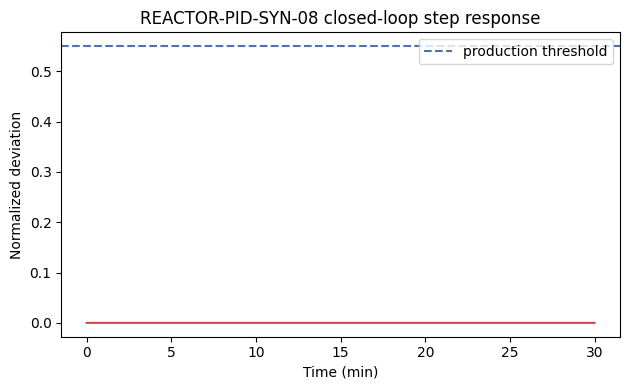

In [14]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(final_response["t_min"], final_response["deviation"], color="#c44e52", linewidth=1.5)
ax.axhline(production_threshold, color="#4c72b0", linestyle="--", label="production threshold")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Normalized deviation")
ax.set_title(f"{project_id} closed-loop step response")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


## Next steps

1. Export DCS faceplate constants for `CSTR-TIC-401` with the production threshold and PID tuple above.
2. Archive the obsolete pilot markdown referencing `staging_threshold=0.30` to avoid operator confusion.
3. Schedule a cold-start verification run using `simulate_step_response` before line turnover.